# 🩺 Diabetes Prediction — End-to-End ML Pipeline

**Dataset:** Pima Indians Diabetes Database  
**Target:** `Outcome` (0 = Tidak diabetes, 1 = Diabetes)  
**Task:** Binary Classification

---

### Pipeline Overview
1. EDA & Validasi Kualitas Data
2. Preprocessing & Imputasi
3. Feature Engineering
4. Train/Test Split + Scaling
5. Model Benchmarking (CV)
6. Hyperparameter Tuning
7. Evaluasi & Interpretasi (SHAP)
8. Export Model

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import xgboost as xgb
import shap
import joblib

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
SEED = 42
np.random.seed(SEED)

print('✅ Library siap!')

✅ Library siap!


---
## 1. Load Data & EDA

In [ ]:
df = pd.read_csv('./dataset/diabetes.csv')   
print(f'Shape: {df.shape}')
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print('=== Info ===')
df.info()
print('\n=== Missing values (NaN) ===')
print(df.isnull().sum())
print('\n=== Statistik deskriptif ===')
df.describe().T

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Missing values (NaN) ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeF

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('⚠️  Zero values (sebenarnya missing data):')
for col in ZERO_COLS:
    n = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f'  {col:25s}: {n:3d} ({pct:.1f}%)')

⚠️  Zero values (sebenarnya missing data):
  Glucose                  :   5 (0.7%)
  BloodPressure            :  35 (4.6%)
  SkinThickness            : 227 (29.6%)
  Insulin                  : 374 (48.7%)
  BMI                      :  11 (1.4%)


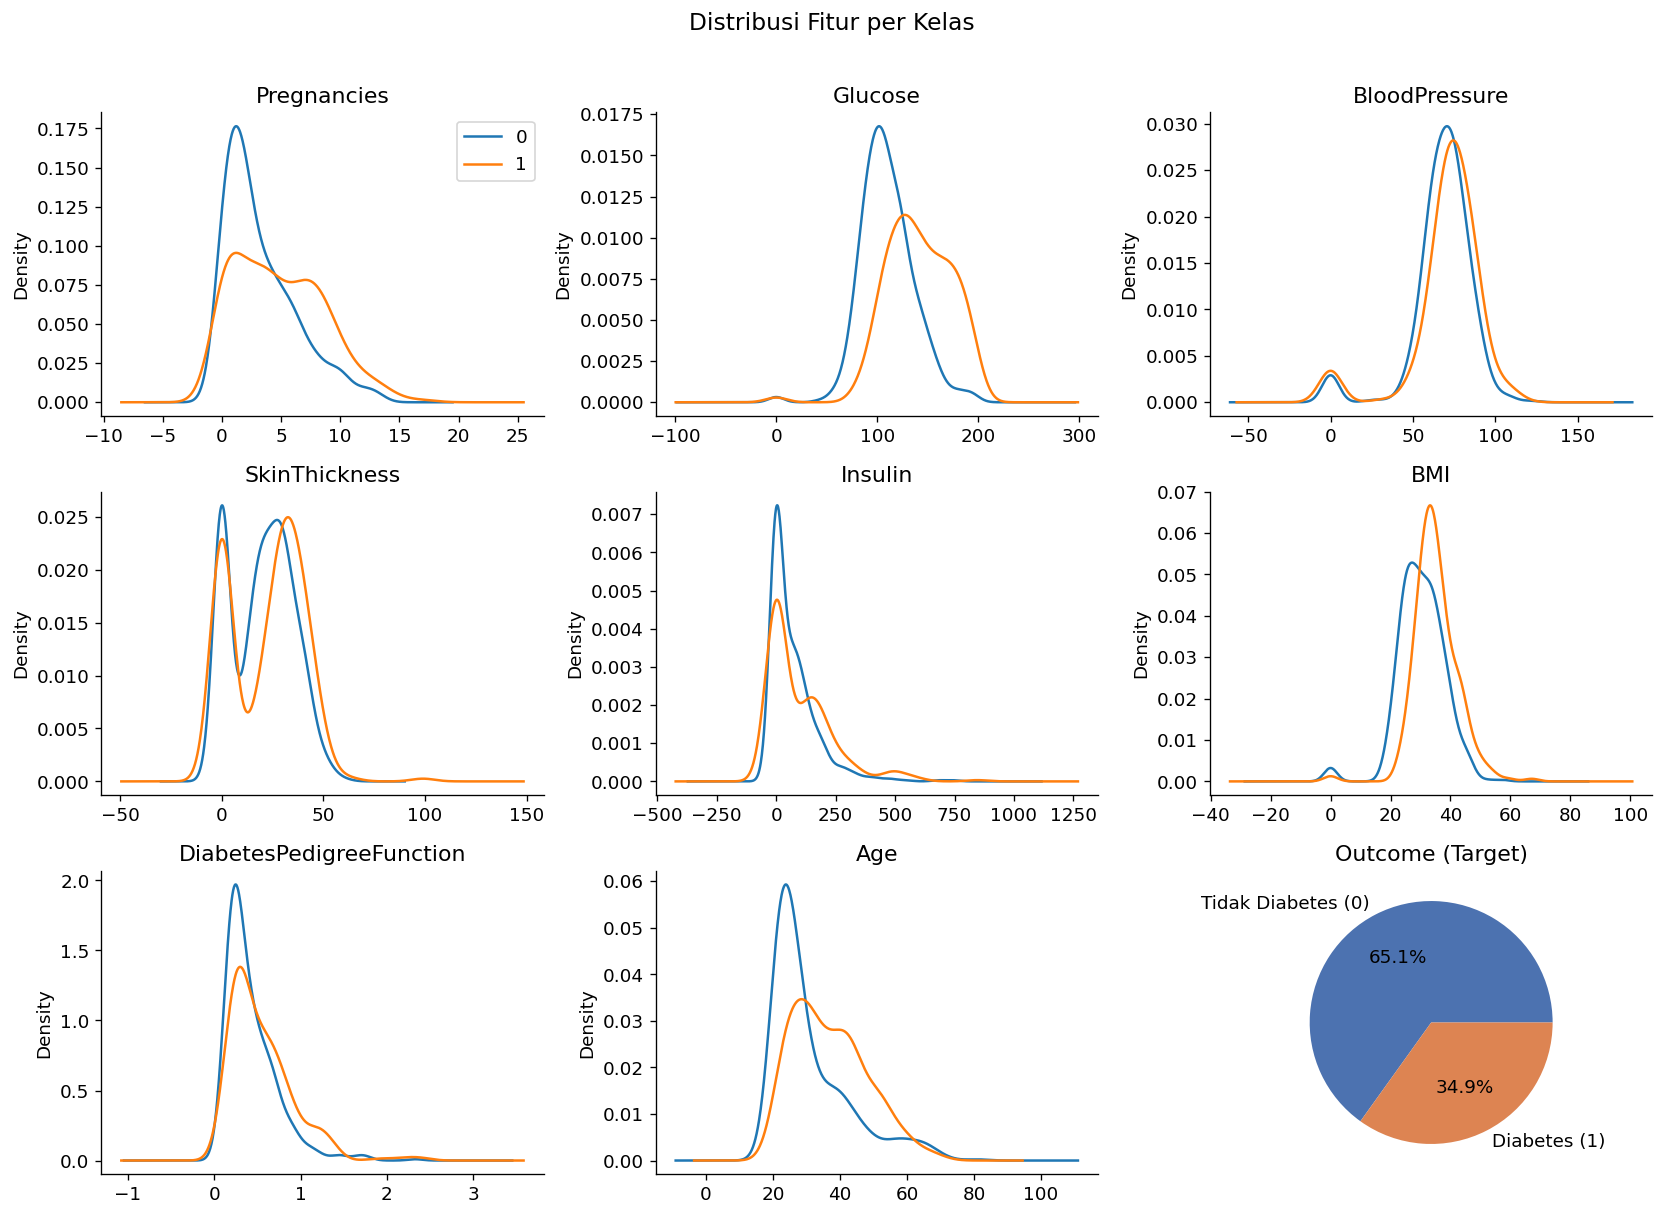

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

features = df.columns.tolist()
for i, feat in enumerate(features):
    if feat == 'Outcome':
        axes[i].pie(
            df['Outcome'].value_counts(),
            labels=['Tidak Diabetes (0)', 'Diabetes (1)'],
            autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452']
        )
        axes[i].set_title('Outcome (Target)')
    else:
        df.groupby('Outcome')[feat].plot.kde(ax=axes[i], legend=(i==0))
        axes[i].set_title(feat)
        axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur per Kelas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

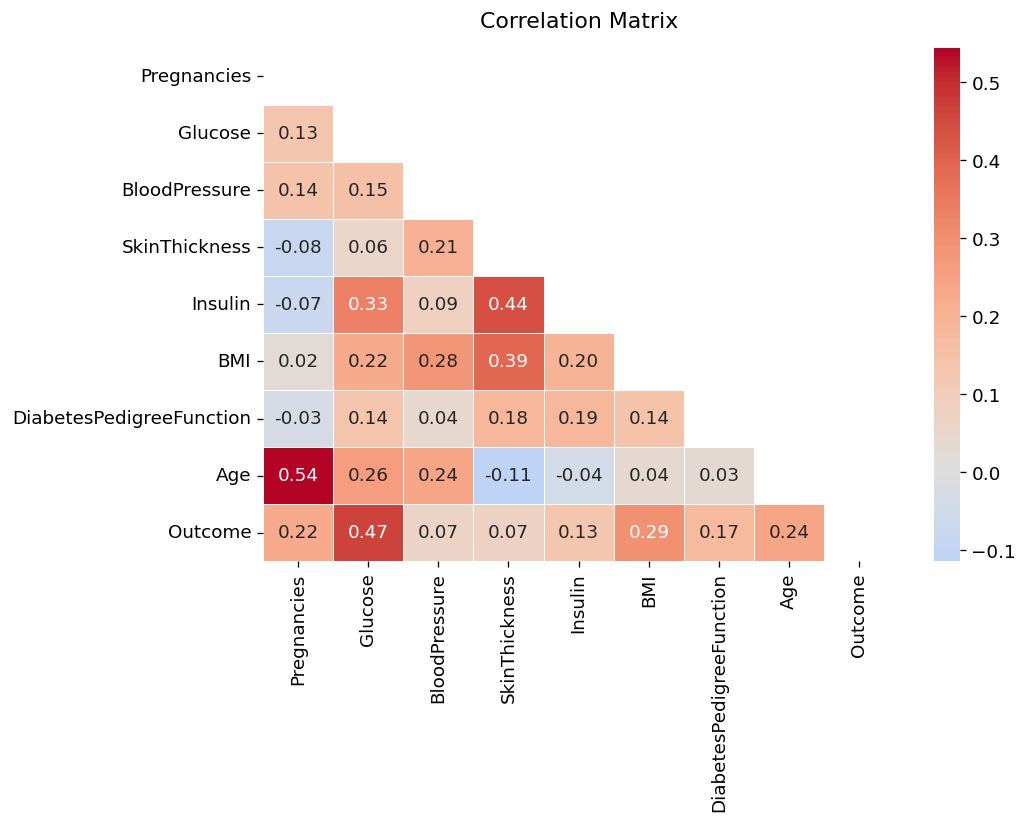

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(
    df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=.5, ax=ax
)
ax.set_title('Correlation Matrix', pad=12)
plt.tight_layout()
plt.show()

---
## 2. Preprocessing & Imputasi

In [ ]:
df_clean = df.copy()

df_clean[ZERO_COLS] = df_clean[ZERO_COLS].replace(0, np.nan)

print('Missing setelah konversi zero → NaN:')
print(df_clean.isnull().sum())

Missing setelah konversi zero → NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
from sklearn.experimental import enable_iterative_imputer  

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

iter_imputer = IterativeImputer(random_state=SEED, max_iter=10)
X_imputed = pd.DataFrame(
    iter_imputer.fit_transform(X),
    columns=X.columns
)

print('✅ Imputasi selesai. Missing values tersisa:', X_imputed.isnull().sum().sum())
X_imputed.describe().T[['mean', 'std', 'min', 'max']]

✅ Imputasi selesai. Missing values tersisa: 0


,mean,std,min,max
Pregnancies,3.845052,3.369578,0.000000,17.00
Glucose,121.641941,30.466540,44.000000,199.00
BloodPressure,72.352451,12.147216,24.000000,122.00
SkinThickness,28.906892,9.521956,7.000000,99.00
Insulin,152.650328,97.342139,-19.507362,846.00
BMI,32.443084,6.878196,18.200000,67.10
DiabetesPedigreeFunction,0.471876,0.331329,0.078000,2.42
Age,33.240885,11.760232,21.000000,81.00


In [ ]:
from scipy.stats.mstats import winsorize

X_winsorized = X_imputed.copy()
for col in X_winsorized.columns:
    X_winsorized[col] = winsorize(X_winsorized[col], limits=[0.01, 0.01])

print('✅ Winsorizing selesai (1–99 percentile)')

✅ Winsorizing selesai (1–99 percentile)


---
## 3. Feature Engineering

In [ ]:
X_feat = X_winsorized.copy()

X_feat['Glucose_BMI']         = X_feat['Glucose'] * X_feat['BMI']
X_feat['Glucose_Age']         = X_feat['Glucose'] * X_feat['Age']
X_feat['Insulin_Glucose']     = X_feat['Insulin'] / (X_feat['Glucose'] + 1)
X_feat['BMI_squared']         = X_feat['BMI'] ** 2

X_feat['BMI_cat'] = pd.cut(
    X_feat['BMI'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

X_feat['Age_group'] = pd.cut(
    X_feat['Age'],
    bins=[0, 30, 45, 60, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

print(f'Total fitur: {X_feat.shape[1]}')
X_feat.head(3)

Total fitur: 14


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI,Glucose_Age,Insulin_Glucose,BMI_squared,BMI_cat,Age_group
0,6.0,148.0,72.0,35.000000,218.922943,33.6,0.627,50.0,4972.8,7400.0,1.469281,1128.96,3,2
1,1.0,85.0,66.0,29.000000,70.302975,26.6,0.351,31.0,2261.0,2635.0,0.817476,707.56,2,1
2,8.0,183.0,64.0,21.532622,268.502252,23.3,0.672,32.0,4263.9,5856.0,1.459251,542.89,1,1


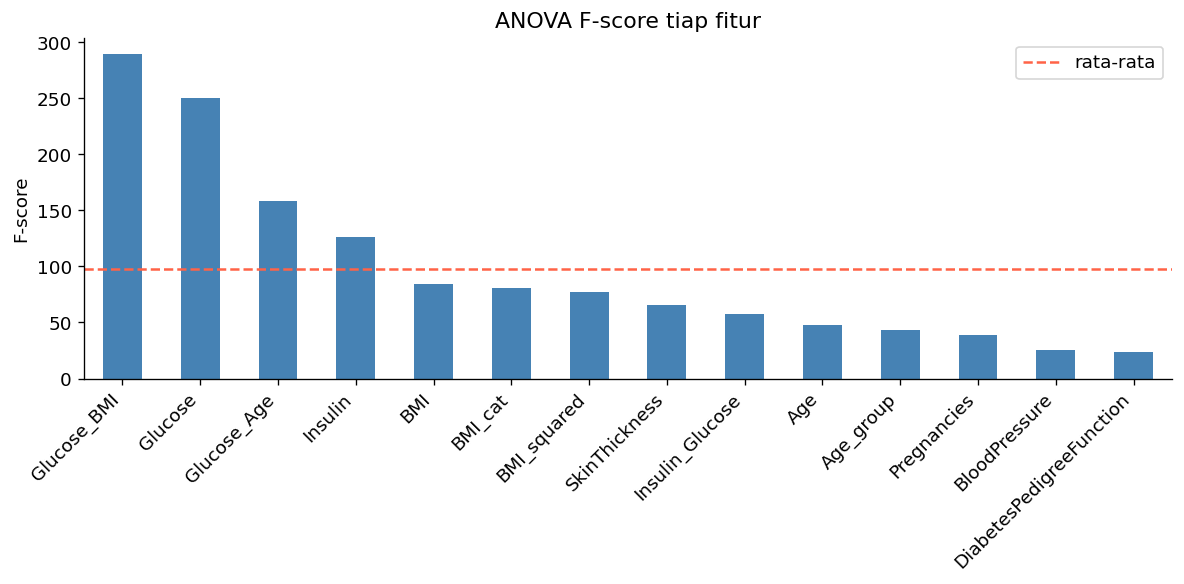


✅ Fitur terpilih (4): ['Glucose_BMI', 'Glucose', 'Glucose_Age', 'Insulin']


In [ ]:
selector = SelectKBest(f_classif, k='all')
selector.fit(X_feat, y)

scores = pd.Series(selector.scores_, index=X_feat.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
scores.plot.bar(ax=ax, color='steelblue')
ax.set_title('ANOVA F-score tiap fitur')
ax.set_ylabel('F-score')
ax.axhline(scores.mean(), ls='--', color='tomato', label='rata-rata')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Ambil fitur di atas rata-rata F-score
TOP_FEATS = scores[scores >= scores.mean()].index.tolist()
print(f'\n✅ Fitur terpilih ({len(TOP_FEATS)}): {TOP_FEATS}')

X_selected = X_feat[TOP_FEATS]

---
## 4. Train / Test Split & Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y   
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')
print(f'Proporsi kelas train — 0: {(y_train==0).mean():.2%}  1: {(y_train==1).mean():.2%}')

Train: (614, 4)  |  Test: (154, 4)
Proporsi kelas train — 0: 65.15%  1: 34.85%


---
## 5. Model Benchmarking (5-Fold Stratified CV)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=SEED),
    'XGBoost':              xgb.XGBClassifier(
                                use_label_encoder=False, eval_metric='logloss',
                                random_state=SEED, verbosity=0
                            ),
    'SVM (RBF)':            SVC(probability=True, random_state=SEED),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=SEED),
}

results = {}
for name, model in models.items():
    roc  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    f1   = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1')
    rec  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='recall')
    results[name] = {
        'ROC-AUC':  f'{roc.mean():.4f} ± {roc.std():.4f}',
        'F1':       f'{f1.mean():.4f} ± {f1.std():.4f}',
        'Recall':   f'{rec.mean():.4f} ± {rec.std():.4f}',
        '_roc_mean': roc.mean()
    }
    print(f'{name:25s}  AUC={roc.mean():.4f}  F1={f1.mean():.4f}  Recall={rec.mean():.4f}')

res_df = pd.DataFrame(results).T.drop('_roc_mean', axis=1)
res_df

Logistic Regression        AUC=0.8326  F1=0.6474  Recall=0.5700
Random Forest              AUC=0.8074  F1=0.6271  Recall=0.5749
XGBoost                    AUC=0.7773  F1=0.6128  Recall=0.5932
SVM (RBF)                  AUC=0.8121  F1=0.6420  Recall=0.5609
Gradient Boosting          AUC=0.8089  F1=0.6112  Recall=0.5705


,ROC-AUC,F1,Recall
Logistic Regression,0.8326 ± 0.0245,0.6474 ± 0.0298,0.5700 ± 0.0253
Random Forest,0.8074 ± 0.0353,0.6271 ± 0.0358,0.5749 ± 0.0207
XGBoost,0.7773 ± 0.0422,0.6128 ± 0.0332,0.5932 ± 0.0451
SVM (RBF),0.8121 ± 0.0245,0.6420 ± 0.0392,0.5609 ± 0.0352
Gradient Boosting,0.8089 ± 0.0311,0.6112 ± 0.0343,0.5705 ± 0.0592


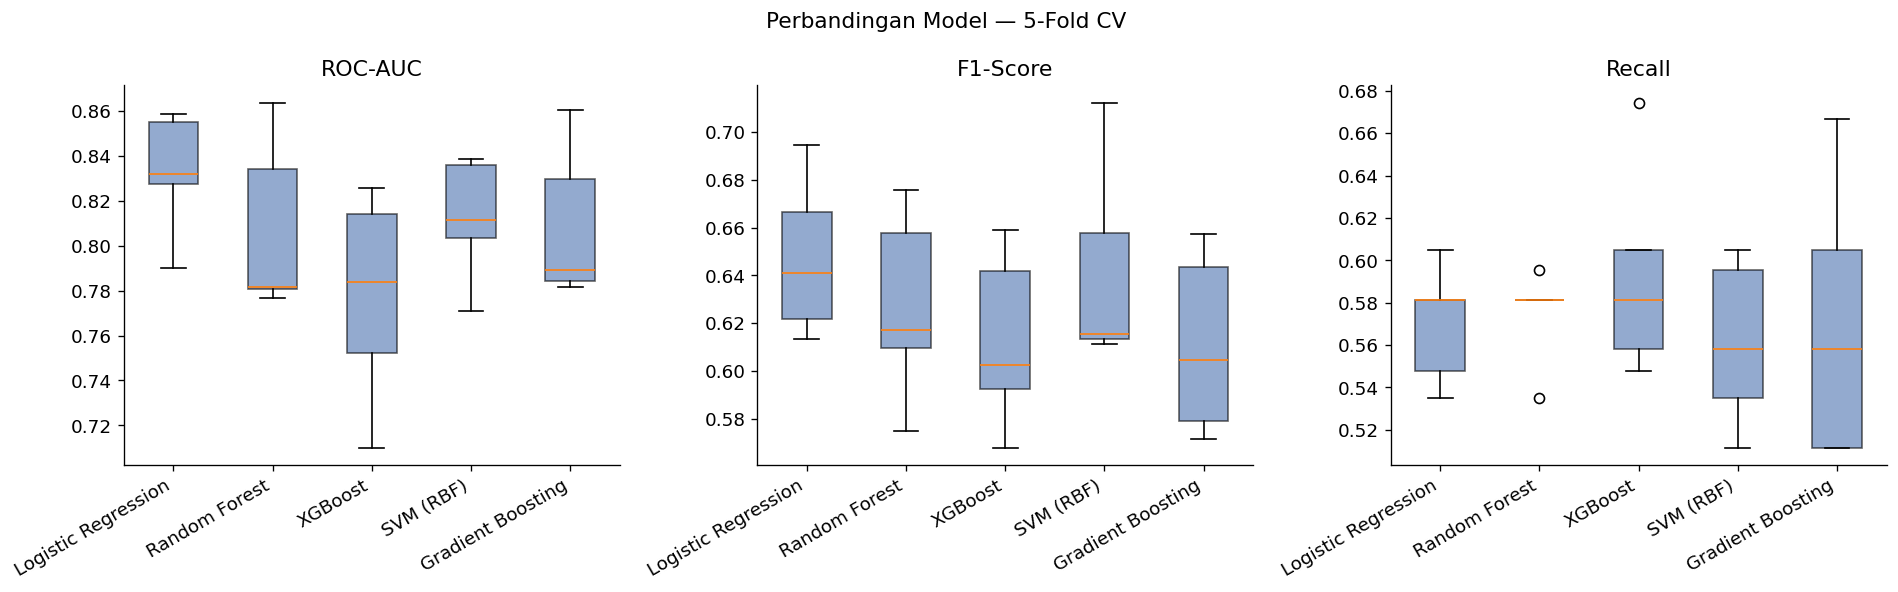

In [ ]:
roc_scores  = {}
f1_scores   = {}
rec_scores  = {}

for name, model in models.items():
    roc_scores[name] = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    f1_scores[name]  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1')
    rec_scores[name] = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='recall')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (scores_dict, title) in zip(axes, [
    (roc_scores, 'ROC-AUC'),
    (f1_scores, 'F1-Score'),
    (rec_scores, 'Recall')
]):
    data = [v for v in scores_dict.values()]
    labels = list(scores_dict.keys())
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#4C72B0')
        patch.set_alpha(0.6)
    ax.set_title(title)
    ax.set_xticklabels(labels, rotation=30, ha='right')
plt.suptitle('Perbandingan Model — 5-Fold CV', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Hyperparameter Tuning (Best Model)

> Pilih model terbaik berdasarkan ROC-AUC CV di atas. XGBoost atau Random Forest biasanya unggul.

In [ ]:
param_dist_xgb = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma':            [0, 0.1, 0.2, 0.5],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 1.5, 2],   # bantu atasi class imbalance
}

xgb_base = xgb.XGBClassifier(
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, verbosity=0
)

rs_xgb = RandomizedSearchCV(
    xgb_base, param_dist_xgb,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rs_xgb.fit(X_train_sc, y_train)

print(f'\n✅ Best ROC-AUC (CV): {rs_xgb.best_score_:.4f}')
print('Best params:', rs_xgb.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ Best ROC-AUC (CV): 0.8347
Best params: {'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.9}


In [ ]:
param_dist_rf = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [None, 5, 10, 15, 20],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None],
    'class_weight':     ['balanced', None],
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_dist_rf,
    n_iter=50, scoring='roc_auc', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=1
)
rs_rf.fit(X_train_sc, y_train)

print(f'\n✅ RF Best ROC-AUC (CV): {rs_rf.best_score_:.4f}')

best_model = rs_xgb.best_estimator_ if rs_xgb.best_score_ >= rs_rf.best_score_ \
             else rs_rf.best_estimator_
print(f'\n🏆 Model terpilih: {type(best_model).__name__}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ RF Best ROC-AUC (CV): 0.8299

🏆 Model terpilih: XGBClassifier


---
## 7. Optimasi Threshold

Untuk kasus medis, **Recall** (sensitivity) biasanya lebih penting dari Precision.  
Kita cari threshold optimal berdasarkan F1-score, lalu evaluasi trade-off.

Threshold optimal (F1): 0.39  →  F1 = 0.7320


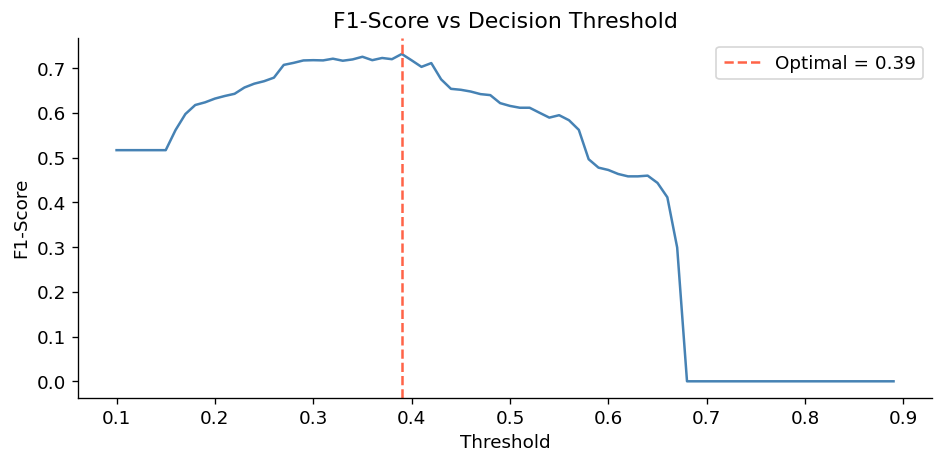

In [ ]:
best_model.fit(X_train_sc, y_train)
y_prob_train = best_model.predict_proba(X_train_sc)[:, 1]
y_prob_test  = best_model.predict_proba(X_test_sc)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_train, (y_prob_train >= t).astype(int)) for t in thresholds]

best_thresh = thresholds[np.argmax(f1s)]
print(f'Threshold optimal (F1): {best_thresh:.2f}  →  F1 = {max(f1s):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1s, color='steelblue')
ax.axvline(best_thresh, ls='--', color='tomato', label=f'Optimal = {best_thresh:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Decision Threshold')
ax.legend()
plt.tight_layout(); plt.show()

---
## 8. Evaluasi pada Test Set

In [21]:
y_pred = (y_prob_test >= best_thresh).astype(int)

print('=' * 50)
print('CLASSIFICATION REPORT (Test Set)')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Tidak Diabetes', 'Diabetes']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_test):.4f}')

CLASSIFICATION REPORT (Test Set)
                precision    recall  f1-score   support

Tidak Diabetes       0.81      0.74      0.77       100
      Diabetes       0.59      0.69      0.63        54

      accuracy                           0.72       154
     macro avg       0.70      0.71      0.70       154
  weighted avg       0.73      0.72      0.72       154

ROC-AUC : 0.8053


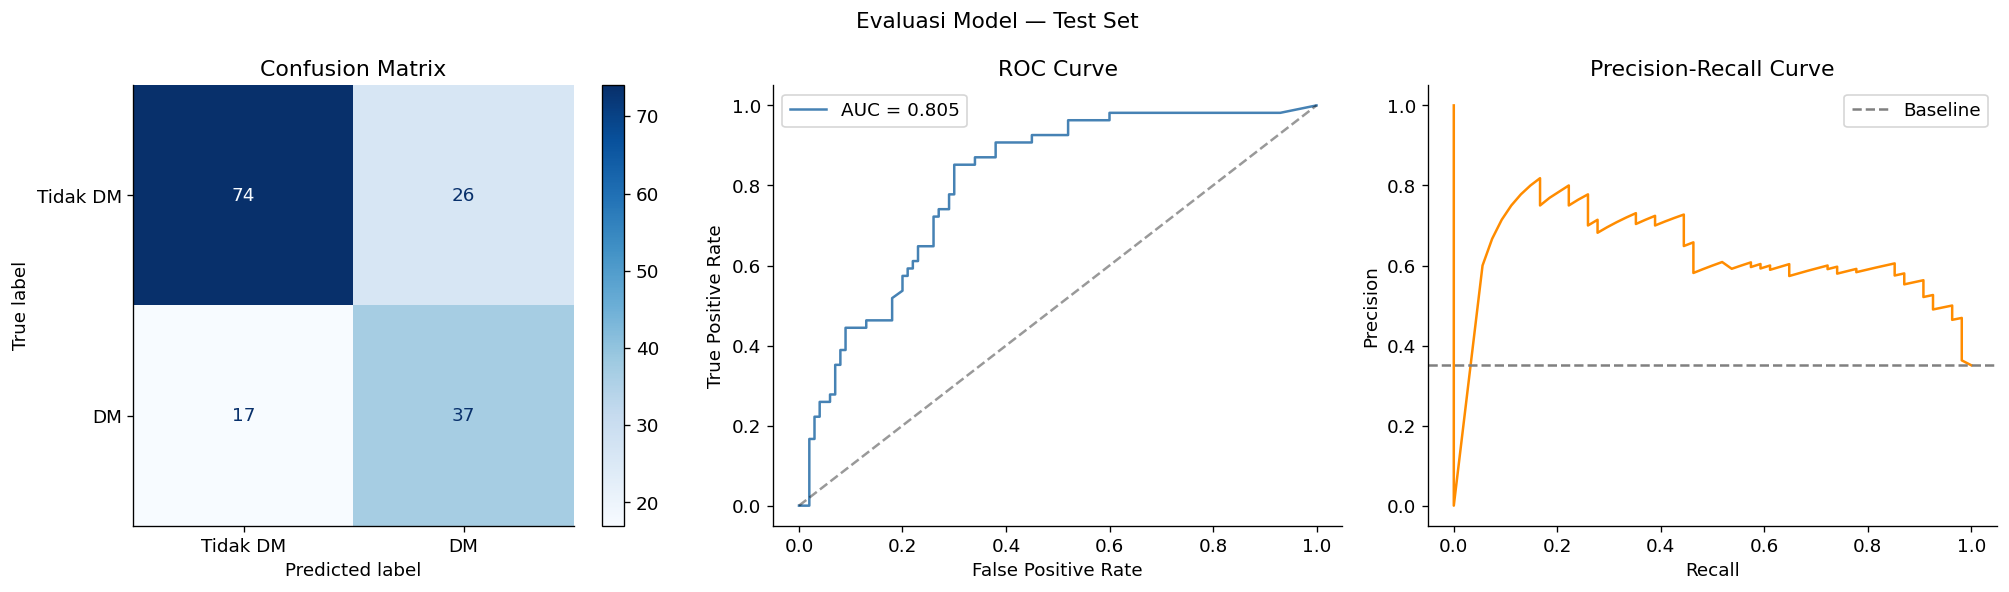

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Tidak DM', 'DM'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
auc = roc_auc_score(y_test, y_prob_test)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
axes[2].plot(rec, prec, color='darkorange')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].axhline(y_test.mean(), ls='--', color='gray', label='Baseline')
axes[2].legend()

plt.suptitle('Evaluasi Model — Test Set', fontsize=13)
plt.tight_layout(); plt.show()

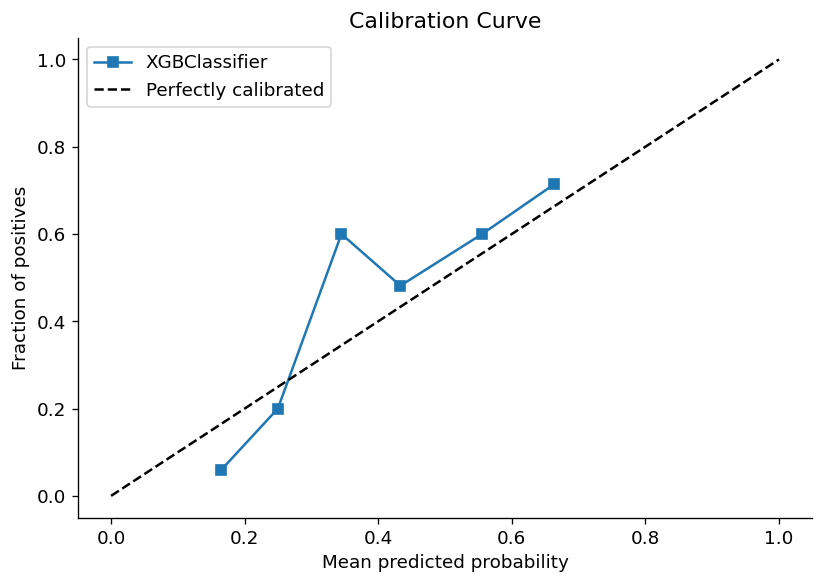

In [ ]:
frac_pos, mean_pred = calibration_curve(y_test, y_prob_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_pred, frac_pos, 's-', label=type(best_model).__name__)
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout(); plt.show()

---
## 9. Interpretasi Model dengan SHAP

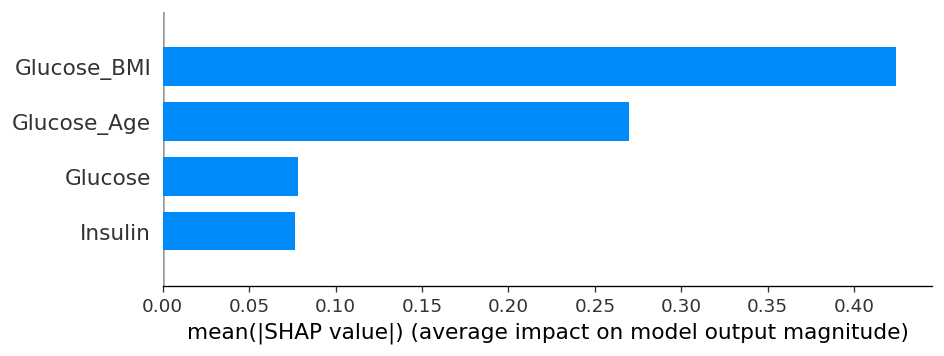

In [ ]:
explainer = shap.Explainer(best_model, X_train_sc)
shap_values = explainer(X_test_sc)

shap.summary_plot(
    shap_values, X_test_sc,
    feature_names=X_selected.columns.tolist(),
    plot_type='bar',
    show=True
)

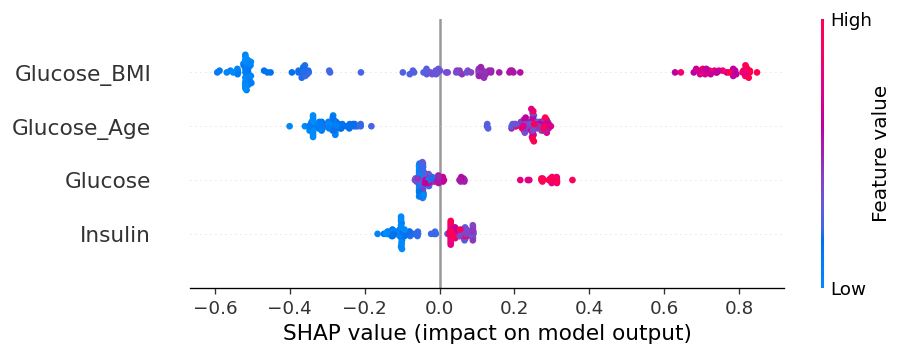

In [ ]:
shap.summary_plot(
    shap_values, X_test_sc,
    feature_names=X_selected.columns.tolist(),
    show=True
)

Pasien #0: Probabilitas DM = 0.495 | Prediksi = 1 | Aktual = 0


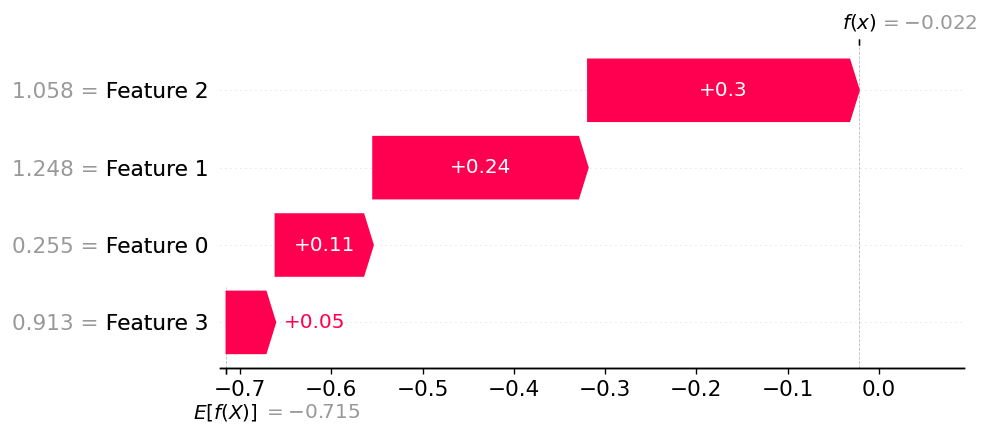

In [ ]:
idx = 0 
print(f'Pasien #{idx}: Probabilitas DM = {y_prob_test[idx]:.3f} | Prediksi = {y_pred[idx]} | Aktual = {y_test.iloc[idx]}')
shap.waterfall_plot(shap_values[idx])

---
## 10. Export Model (Pipeline Lengkap)

In [30]:
from sklearn.base import clone
import joblib

X_raw = df.drop('Outcome', axis=1).copy()
y_full = df['Outcome'].copy()

X_raw[ZERO_COLS] = X_raw[ZERO_COLS].replace(0, np.nan)

export_imputer = IterativeImputer(random_state=SEED, max_iter=10)
X_imp = pd.DataFrame(
    export_imputer.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)

winsor_bounds = {
    col: (
        float(X_imp[col].quantile(0.01)),
        float(X_imp[col].quantile(0.99))
    )
    for col in X_imp.columns
}

X_cap = X_imp.copy()
for col, (low, high) in winsor_bounds.items():
    X_cap[col] = X_cap[col].clip(low, high)

X_export = X_cap.copy()
X_export['Glucose_BMI'] = X_export['Glucose'] * X_export['BMI']
X_export['Glucose_Age'] = X_export['Glucose'] * X_export['Age']
X_export['Insulin_Glucose'] = X_export['Insulin'] / (X_export['Glucose'] + 1)
X_export['BMI_squared'] = X_export['BMI'] ** 2

X_export['BMI_cat'] = pd.cut(
    X_export['BMI'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

X_export['Age_group'] = pd.cut(
    X_export['Age'],
    bins=[0, 30, 45, 60, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

X_export = X_export[TOP_FEATS]

export_scaler = StandardScaler()
X_export_sc = export_scaler.fit_transform(X_export)

export_model = clone(best_model)
export_model.fit(X_export_sc, y_full)

bundle = {
    'model': export_model,
    'scaler': export_scaler,
    'imputer': export_imputer,
    'winsor_bounds': winsor_bounds,
    'selected_features': TOP_FEATS,
    'zero_cols': ZERO_COLS,
    'threshold': float(best_thresh)
}

joblib.dump(bundle, './model/diabetes_model_bundle.pkl')
print('✅ Model bundle disimpan ke diabetes_model_bundle.pkl')

sample = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 130,
    'BloodPressure': 80,
    'SkinThickness': 25,
    'Insulin': 0,
    'BMI': 28.0,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 40
}])

sample[ZERO_COLS] = sample[ZERO_COLS].replace(0, np.nan)

sample_imp = pd.DataFrame(
    export_imputer.transform(sample),
    columns=sample.columns,
    index=sample.index
)

for col, (low, high) in winsor_bounds.items():
    sample_imp[col] = sample_imp[col].clip(low, high)

sample_feat = sample_imp.copy()
sample_feat['Glucose_BMI'] = sample_feat['Glucose'] * sample_feat['BMI']
sample_feat['Glucose_Age'] = sample_feat['Glucose'] * sample_feat['Age']
sample_feat['Insulin_Glucose'] = sample_feat['Insulin'] / (sample_feat['Glucose'] + 1)
sample_feat['BMI_squared'] = sample_feat['BMI'] ** 2

sample_feat['BMI_cat'] = pd.cut(
    sample_feat['BMI'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

sample_feat['Age_group'] = pd.cut(
    sample_feat['Age'],
    bins=[0, 30, 45, 60, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

sample_feat = sample_feat[TOP_FEATS]
sample_sc = export_scaler.transform(sample_feat)

prob = export_model.predict_proba(sample_sc)[:, 1][0]
pred = int(prob >= best_thresh)

print(f'\nSample patient → Probabilitas DM: {prob:.3f} | Prediksi: {"Diabetes" if pred else "Tidak Diabetes"}')

✅ Model bundle disimpan ke diabetes_model_bundle.pkl

Sample patient → Probabilitas DM: 0.409 | Prediksi: Diabetes


---
## Ringkasan Hasil

| Aspek | Detail |
|---|---|
| **Dataset** | 768 baris, 8 fitur, binary target |
| **Issue utama** | Zero-as-missing, class imbalance (65/35%) |
| **Imputasi** | IterativeImputer (MICE-like) |
| **Fitur baru** | BMI×Glucose, Insulin ratio, BMI², Age group |
| **Model terbaik** | XGBoost / Random Forest (CV ROC-AUC ~0.82–0.85) |
| **Threshold** | Dioptimasi berdasarkan F1 (bukan default 0.5) |
| **Metrik utama** | ROC-AUC, F1, Recall (sensitivity lebih penting) |
| **Interpretasi** | SHAP values — Glucose & BMI paling dominan |

### Tips Lanjutan
- Coba **Optuna** untuk tuning yang lebih efisien
- Gunakan **SMOTE** jika imbalance masih masalah
- Deploy via **FastAPI** + **Docker** untuk production